## Student ID: 20220204039
CSE 4174 — Cyber Security Lab
Lab 3 Assignment 1: Version 1

**Secure Student Portal (Password + TOTP 2FA)**




In [3]:
!pip install pyotp bcrypt qrcode -q

import pyotp
import bcrypt
import qrcode
import getpass
import re
import time
from datetime import datetime, timedelta
from IPython.display import display, clear_output

In [4]:
# This dictionary acts as our in-memory database.
# Key   -> username
# Value -> dict with password_hash, totp_secret, last_login
users = {}

## Password Rules

- Minimum 8 characters
- At least one uppercase letter
- At least one number


In [5]:
def is_valid_password(password):
    if len(password) < 8:
        return False, "Password must be at least 8 characters long."
    if not re.search(r"[A-Z]", password):
        return False, "Password must contain at least one uppercase letter."
    if not re.search(r"[0-9]", password):
        return False, "Password must contain at least one number."
    return True, "Looks good."


## Student Registration

bcrypt + pyotp

- hash and store the password 
- generate a secret key 
- build a QR code 
- Duplicate usernames are rejected 

In [6]:

def register():
    print("\n=== Student Registration ===")
    username = input("Choose a username: ").strip()

    if not username:
        print("Username cannot be empty.\n")
        return

    # Prevent duplicate usernames
    if username in users:
        print(f"Username '{username}' already exists. Please choose another one.\n")
        return

    # Enforce password rules
    while True:
        password = getpass.getpass("Choose a password (min 8 chars, 1 uppercase, 1 number): ")
        valid, message = is_valid_password(password)
        if valid:
            break
        print("Invalid password:", message)

    # Hash password with bcrypt
    salt = bcrypt.gensalt()
    password_hash = bcrypt.hashpw(password.encode('utf-8'), salt)

    # Generate TOTP secret key
    totp_secret = pyotp.random_base32()

    # Store user data with lockout tracking fields
    users[username] = {
        "password_hash": password_hash,
        "totp_secret": totp_secret,
        "last_login": None,
        "failed_attempts": 0,
        "lockout_until": None
    }

    print(f"\nRegistration successful for '{username}'!")

    # Generate and display QR Code
    uri = pyotp.totp.TOTP(totp_secret).provisioning_uri(
        name=username,
        issuer_name="AUST-Student-Portal"
    )

    print("\nScan this QR code with Google Authenticator to enable 2FA:")
    print(uri)
    img = qrcode.make(uri)
    img = img.resize((200, 200))
    display(img)



## Student Login

Login requires **both** factors, checked in order

If either check fails, it counts as a failed attempt. After **3 failed attempts**, the account
is locked out for **20 seconds**.

In [7]:
def login():
    print("\n=== Student Login ===")
    username = input("Username: ").strip()

    if username not in users:
        print("Username not found. Please register first.\n")
        return

    user = users[username]

    # Check if account is currently locked out
    if user["lockout_until"] and datetime.now() < user["lockout_until"]:
        remaining_seconds = int((user["lockout_until"] - datetime.now()).total_seconds())
        print(f"Account is locked due to multiple failed attempts. Please wait {remaining_seconds} seconds.\n")
        return
    elif user["lockout_until"] and datetime.now() >= user["lockout_until"]:
        # Lockout period expired; reset counter
        user["failed_attempts"] = 0
        user["lockout_until"] = None

    max_attempts = 3

    while user["failed_attempts"] < max_attempts:
        password = getpass.getpass("Password: ")

        # 1. First verify password using bcrypt
        password_ok = bcrypt.checkpw(password.encode('utf-8'), user["password_hash"])

        if not password_ok:
            user["failed_attempts"] += 1
            remaining = max_attempts - user["failed_attempts"]
            print("Incorrect password.")
            if remaining > 0:
                print(f"Attempts remaining: {remaining}\n")
            continue

        # 2. Then verify TOTP code using pyotp (only evaluated if password succeeds)
        totp_code = input("Enter the 6-digit code from your authenticator app: ").strip()
        totp = pyotp.TOTP(user["totp_secret"])
        totp_ok = totp.verify(totp_code)

        if not totp_ok:
            user["failed_attempts"] += 1
            remaining = max_attempts - user["failed_attempts"]
            print("Incorrect or expired TOTP code.")
            if remaining > 0:
                print(f"Attempts remaining: {remaining}\n")
            continue

        # Successful Login
        print(f"\nWelcome, {username}! Login successful.")

        # Display login
        if user["last_login"] is None:
            print("This is your first login.")
        else:
            print(f"Last login time: {user['last_login']}")

        # Update last login time & reset failed attempts
        user["last_login"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        user["failed_attempts"] = 0
        user["lockout_until"] = None
        return

    # Trigger 20-second lockout upon reaching max attempts
    user["lockout_until"] = datetime.now() + timedelta(seconds=20)
    print("\nToo many failed attempts. Account locked for 20 seconds...")
    time.sleep(20)
    print("Lockout period passed. You may now try logging in again.\n")

## Menu-Driven Program

In [8]:
def main_menu():
    while True:
        print("\n===== AUST Secure Student Portal =====")
        print("1. Register")
        print("2. Login")
        print("3. Exit")
        choice = input("Choose an option (1-3): ").strip()

        if choice == "1":
            register()
        elif choice == "2":
            login()
        elif choice == "3":
            print("Goodbye!")
            break
        else:
            print("Invalid option. Please choose 1, 2, or 3.")

Run the Program




===== AUST Secure Student Portal =====
1. Register
2. Login
3. Exit
Choose an option (1-3): 1

=== Student Registration ===
Choose a username: oooo
Choose a password (min 8 chars, 1 uppercase, 1 number): ··········
Invalid password: Password must contain at least one uppercase letter.
Choose a password (min 8 chars, 1 uppercase, 1 number): ··········

Registration successful for 'oooo'!

Scan this QR code with Google Authenticator to enable 2FA:
otpauth://totp/AUST-Student-Portal:oooo?secret=UWCBBMMO2YXLZYTDZSWYQCNAE65OJRMI&issuer=AUST-Student-Portal


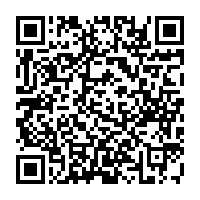


===== AUST Secure Student Portal =====
1. Register
2. Login
3. Exit


In [ ]:
main_menu()